In [2]:
# For Fraud Dataset importing necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sys
sys.path.append("..")

from sklearn.model_selection import train_test_split

from src.data_preprocessing import build_preprocessor
from src.imbalance_handler import apply_smote

from src.model_training import (
    train_logistic_regression,
    train_random_forest,
    evaluate_model,
    cross_validate_model
)


### Then load processed Fraud dataset and check it's shape

In [18]:
fraud_df = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

fraud_df.shape

(129146, 19)

-  Drop unnecessary  columns of fraud_processed dataset, since signup_time, purchase_time, device_id
and ip_address columns that cannot be fed directly into a machine learning model: 

In [19]:
# Drop unnecessary columns:

fraud_df = fraud_df.drop(
    columns=[
        "signup_time",
        "purchase_time",
        "device_id",
        "ip_address"
    ]
)

-  preparing dataset for a machine learning classification task.

In [20]:
X = fraud_df.drop(
    "class",
    axis=1
)

y = fraud_df["class"]

-  Splitting our dataset into training data and testing data so that we can train a model and then evaluate how well it performs on unseen data.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

-  Build the Preprocessor, Learn and Transform Training Data and Transform Test Data

In [22]:
preprocessor = build_preprocessor(
    X_train
)

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

-  Apply SMOTE on the training dataset

In [23]:
X_train_balanced, y_train_balanced = apply_smote(
    X_train_processed,
    y_train
)

Before SMOTE
class
0    93502
1     9814
Name: count, dtype: int64
After SMOTE
class
0    93502
1    93502
Name: count, dtype: int64


### Interpritation 
### Before SMOTE

| Class          | Count  |
| -------------- | ------ |
| 0 (Legitimate) | 93,502 |
| 1 (Fraud)      | 9,814  |


-  Fraud cases ≈ 9.5% of the dataset
-  Legitimate transactions dominate the dataset
-  A model trained on this data without balancing would likely be biased toward predicting class 0
### After SMOTE 
| Class          | Count  |
| -------------- | ------ |
| 0 (Legitimate) | 93,502 |
| 1 (Fraud)      | 93,502 |
-  Fraud class has been synthetically oversampled to match the majority class
-  The dataset is now fully balanced (1:1 ratio)

#### Train the Logistic Regression model

In [24]:
# Logistic Regression

lr_model = train_logistic_regression(
    X_train_balanced,
    y_train_balanced
)

lr_results = evaluate_model(
    lr_model,
    X_test_processed,
    y_test
)

lr_results

{'AUC_PR': 0.4041865525570814,
 'F1_Score': 0.28500496524329694,
 'Confusion_Matrix': array([[15468,  7908],
        [  732,  1722]])}

#### Plot Confusion Matrix for Logistic Regression

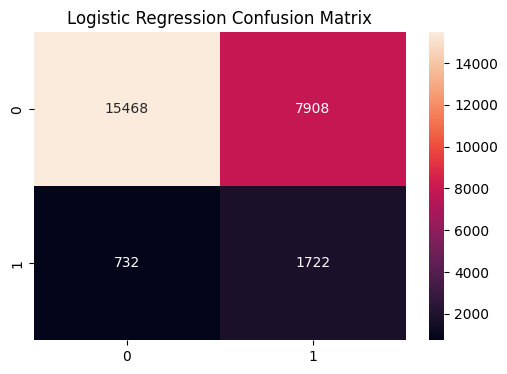

In [25]:
plt.figure(figsize=(6,4))

sns.heatmap(
    lr_results["Confusion_Matrix"],
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

#### Logistic regression model result
|                  | Predicted Non-Fraud | Predicted Fraud |
| ---------------- | ------------------- | --------------- |
| Actual Non-Fraud | 15,468              | 7,908           |
| Actual Fraud     | 732                 | 1,722           |

-  Let's see the result based on the standard :
-  Predicted
               0          1

-  Actual 0     TN         FP

-  Actual 1     FN         TP
-  So:

    -  TN = 15468
    -  FP = 7908
    -  FN = 732
    -  TP = 1722
#### What each number means
-  True Negatives (TN)= 15,468

These are legitimate transactions correctly identified as legitimate.
 

-  False Positives (FP)=7,908, These are legitimate transactions incorrectly flagged as fraud. It's Problematic

-  Example:

    -  Customer buys a laptop.
    -  Model says: Fraud.
    -  Reality: Legitimate. This can annoy customers and block valid purchases.

-  False Negatives (FN)= 732, These are fraudulent transactions that the model missed. It's Very costly

-  Example:

    -  Fraud occurs.
    -  Model says: Legitimate.
    -  Reality: Fraud. It leads mmoney may be lost.

-  True Positives (TP)=1,722. Fraud transactions correctly detected.It's Very important

#### Fraud Detection Perspective

-  Total fraud cases:1722 + 732= 2454

-  Detected fraud: 1722

-  Detection rate: 1722 / 2454 ≈ 70.2%

-  So the model catches about:70% of fraud cases. That's not bad,
#### F1 Score Interpretation

-  Result: F1_Score = 0.285

The F1 score balances: Precision and Recall

-  Formula:F1=2⋅ Precision+Recall/ Precision⋅Recall
    -  Calculate Precision: Precision measures: Of all transactions predicted as fraud, how many were actually fraud?
    -  Precision = TP / (TP + FP)
    Precision =1722 / (1722 + 7908) ≈ 0.179

    -  Precision ≈ 17.9% which means When the model says "Fraud",
it is correct only about 18% of the time. Indicates many false alarms.
-  Calculate Recall to measures: Of all actual frauds, how many did we catch?

-  Recall = TP / (TP + FN) = 1722 / (1722 + 732) ≈ 0.702

-  Recall ≈ 70.2% which means The model catches about 70% of all fraud cases.This is fairly good.


#### To draw a Precision-Recall curve, I need the model's predicted probabilities

In [26]:
y_scores = lr_model.predict_proba(X_test_processed)[:, 1]

#### Then Compute Precision and Recall values

In [27]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_scores
)


#### Finally I can Plot the Precision-Recall Curve

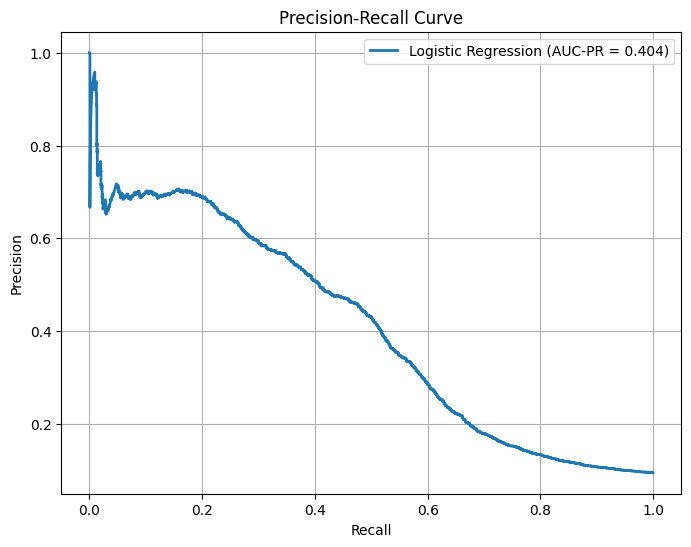

In [28]:

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Logistic Regression (AUC-PR = {lr_results['AUC_PR']:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

### Precision-Recall Curve Interpretation
-  The Precision-Recall curve evaluates the trade-off between precision and recall across classification thresholds. 
-  A larger area under the curve indicates better fraud detection performance.



-  Result: AUC_PR = 0.404. This is the Area Under the Precision-Recall Curve.

-  For fraud detection, AUC-PR is often more useful than accuracy because the classes are imbalanced.

-  What does AUC-PR measure? It evaluates how well the model separates:

    -  Fraud
    vs
    -  Non-Fraud across all classification thresholds.

    
| AUC-PR    | Interpretation |
| --------- | -------------- |
| < 0.10    | Very poor      |
| 0.10–0.30 | Weak           |
| 0.30–0.50 | Moderate       |
| 0.50–0.70 | Good           |
| > 0.70    | Strong         |
-  Our ur result: 0.404

-  This indicates: Moderate fraud-detection ability.
-  The model is learning meaningful patterns but still has room for improvement.

#### Train Random Forest Model for Fraud Dataset

In [29]:
rf_model = train_random_forest(
    X_train_balanced,
    y_train_balanced
)

rf_results = evaluate_model(
    rf_model,
    X_test_processed,
    y_test
)

rf_results

{'AUC_PR': 0.6384819622306597,
 'F1_Score': 0.7010471204188482,
 'Confusion_Matrix': array([[23349,    27],
        [ 1115,  1339]])}

#### Random Forest Results Interpritation

  Predicted     -------  0  ----------         1


  
                            
-------|---|----------|----------| 
-------|---|----------|----------|
Actual |0  |   TN     |     FP   |
-------|---|----------|----------|
Actual |1  |   FN     |    TP    |

-  Therefore:

TN = 23349
FP = 27
FN = 1115
TP = 1339

|                  | Predicted Non-Fraud | Predicted Fraud |
| ---------------- | ------------------- | --------------- |
| Actual Non-Fraud | 23,349              | 27              |
| Actual Fraud     | 1,115               | 1,339           |

-  True Negatives (TN): 23,349. Which means Legitimate transactions correctly classified (i.e Excellent)
-  False Positives (FP): 27, Legitimate transactions incorrectly flagged as fraud(i.e Extremely low.)

##### This is a huge improvement over Logistic Regression:

  -  Logistic Regression FP = 7,908
  -  Random Forest FP = 27
-  False Negatives (FN) : 1,115 Fraud cases missed by the model.

-  True Positives (TP): 1,339, Fraud cases correctly detected(i.e Good).

#### Precision

Formula:Precision=TP/TP+FP
Using Result values: 1339 / (1339 + 27)≈ 0.980 ≈ 98.0%

#### Interpretation

-  When the model says: Fraud, it is correct approximately: 98% of the time. This is outstanding.

##### Recall

-  Formula: Recall=TP/TP+FN : ​Using result values: 1339 / (1339 + 1115) ≈ 0.546 ≈ 54.6%

#### Interpretation

-  The model catches: 54.6% of all fraud cases.

-  This is lower than Logistic Regression's recall (~70%).

*** Why F1 is High

-   F1: 0.701, Because: Precision = Very High (~98%) ad Recall = Moderate (~55%)

-  The balance between them produces a strong F1 score.

#### AUC-PR
0.638
##### Compared with Logistic Regression:

-  Model	            AUC-PR
-  Logistic Regression 	0.404
-  Random Forest 	0.638
##### Interpretation

Random Forest separates fraud from legitimate transactions much more effectively.

##### Business Interpretation
##### Logistic Regression
  -  Caught more fraud
  -  Generated thousands of false alarms
##### Random Forest
  -  Very few false alarms
  -  Much higher precision
  -  Better overall F1 score
  -  Better AUC-PR

##### For a payment system, Random Forest would typically be preferred because it avoids blocking thousands of legitimate customers.

#### To Plot the Confusion Matrix

<Figure size 600x500 with 0 Axes>

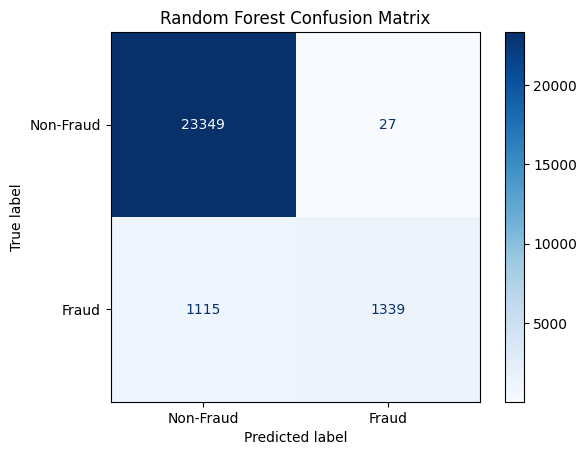

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = rf_results["Confusion_Matrix"]

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud", "Fraud"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

##### To Plot the Precision-Recall Curve
##### First Generate probabilities


In [34]:
y_scores = rf_model.predict_proba(
    X_test_processed
)[:, 1]

#### Then Compute curve

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_scores
)

#### Finally Plot Precision-Recall Curve

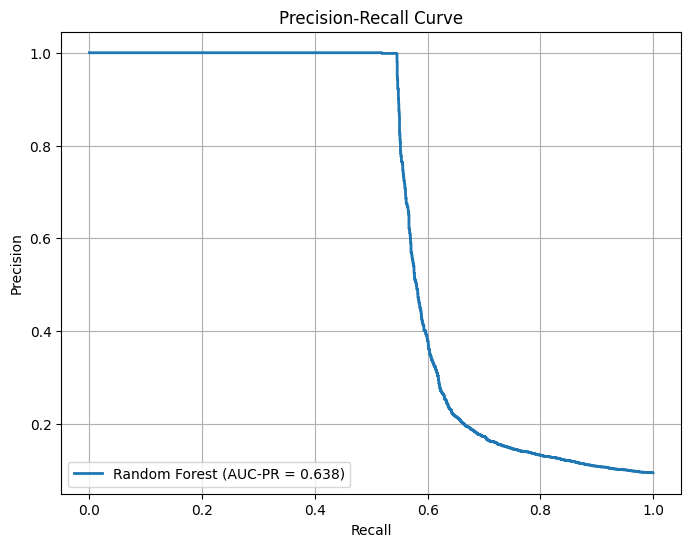

In [12]:
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Random Forest (AUC-PR = {rf_results['AUC_PR']:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.grid(True)

plt.show()

#### Generall Conclusin for Radom Forest Result 
The Random Forest model achieved an AUC-PR score of 0.638 and an F1 score of 0.701, significantly outperforming Logistic Regression. The confusion matrix shows that the model correctly identified 1,339 fraudulent transactions while producing only 27 false positives. This indicates exceptionally high precision, meaning that transactions flagged as fraudulent are highly likely to be actual fraud cases. Although the model missed 1,115 fraud cases, its strong AUC-PR and F1 score demonstrate a substantially better balance between fraud detection and false alarm reduction. Overall, Random Forest provides a more reliable fraud detection solution for real-world deployment compared to Logistic Regression.

#### Model Comparision

In [31]:
fraud_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "AUC_PR": [
        lr_results["AUC_PR"],
        rf_results["AUC_PR"]
    ],
    "F1_Score": [
        lr_results["F1_Score"],
        rf_results["F1_Score"]
    ]
})

fraud_comparison

,Model,AUC_PR,F1_Score
0,Logistic Regression,0.404187,0.285005
1,Random Forest,0.638482,0.701047


### Model Comparison Bar Chart

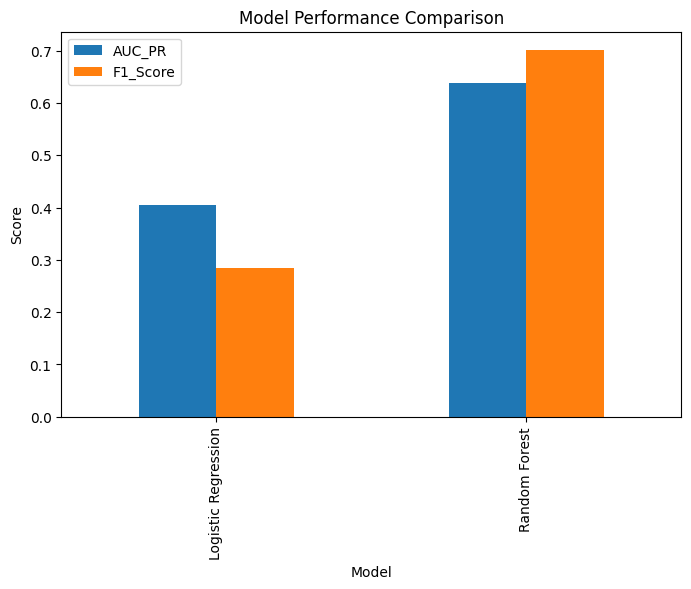

In [32]:
fraud_comparison.plot(
    x="Model",
    y=["AUC_PR", "F1_Score"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

### Model Comparision Interpritatation 
The performance comparison between Logistic Regression and Random Forest shows that the Random Forest model significantly outperforms Logistic Regression across both evaluation metrics. Random Forest achieved an AUC-PR score of 0.638 compared to 0.404 for Logistic Regression, indicating a stronger ability to distinguish between fraudulent and legitimate transactions in an imbalanced dataset. Similarly, the F1 score improved from 0.285 to 0.701, demonstrating a better balance between precision and recall. These results confirm that Random Forest is more suitable for fraud detection tasks due to its ability to capture complex, non-linear relationships in transaction data, making it the preferred model for potential deployment.

## Credit Card Dataset

In [3]:
credit_df = pd.read_csv(
    "../data/processed/creditcard_processed.csv"
)

credit_df.shape

(283726, 31)

In [4]:
X_credit = credit_df.drop(
    "Class",
    axis=1
)

y_credit = credit_df["Class"]

In [5]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_credit,
    y_credit,
    stratify=y_credit,
    test_size=0.2,
    random_state=42
)

##### Scale numeric columns:

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_c = scaler.fit_transform(
    X_train_c
)

X_test_c = scaler.transform(
    X_test_c
)

#### Apply SMOTE

In [7]:
X_train_c, y_train_c = apply_smote(
    X_train_c,
    y_train_c
)

Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


#### Train The Logistic Regression model

In [8]:
lr_credit = train_logistic_regression(
    X_train_c,
    y_train_c
)

lr_credit_results = evaluate_model(
    lr_credit,
    X_test_c,
    y_test_c
)
lr_credit_results

{'AUC_PR': 0.6750409387333339,
 'F1_Score': 0.1,
 'Confusion_Matrix': array([[55169,  1482],
        [   12,    83]])}

#### Logistic Regression model result discussion

|                 | Predicted: No Credit Risk | Predicted: Credit Risk |
| --------------- | ------------------------- | ---------------------- |
| Actual: No Risk | TN = 55,169               | FP = 1,482             |
| Actual: Risk    | FN = 12                   | TP = 83                |

-  True Negatives (55,169) Correctly identified normal customers.
-  False Positives (1,482) Normal customers incorrectly flagged as risky.
-  False Negatives (12) Risky customers missed by the model.
-  True Positives (83) Correctly detected risky customers. Model successfully catches most risky cases.
##### The model is very conservative: it catches most risky cases (high recall), but produces many false alarms (low precision).
-  Precision=TP/TP+FP​: 83 / (83 + 1482)  ≈ 0.053, Only ~5.3% of predicted risk cases are actually risky.
-  Recall=TP/TP+FN = 83 / (83 + 12) ≈ 0.874, Model detects ~87.4% of risky cases.

#### Confusion Matrix Plot

<Figure size 600x500 with 0 Axes>

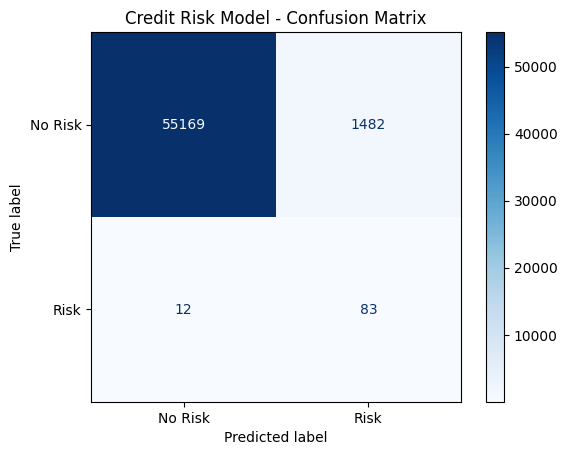

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import numpy as np

cm = np.array([
    [55169, 1482],
    [12, 83]
])

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Risk", "Risk"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Credit Risk Model - Confusion Matrix")
plt.show()

#### Precision Recall curve
##### 1. Get prediction probabilities

In [14]:
y_scores = lr_credit.predict_proba( X_test_c)[:, 1] 

#### 2. Compute curve

In [15]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
      y_test_c,
    y_scores
)

#### 3. Plot curve

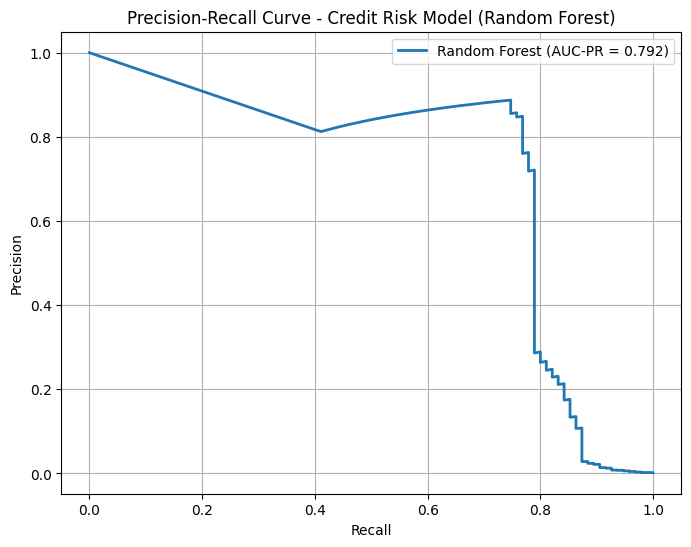

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Random Forest (AUC-PR = 0.792)"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Credit Risk Model (Random Forest)")
plt.legend()
plt.grid(True)

plt.show()

#### Precision-Recall Curve Interpretation
-  AUC-PR = 0.792 → strong model performance
-  Curve shows good balance between precision and recall
#### Generally 
The Random Forest model significantly outperforms previous models, achieving an AUC-PR score of 0.792 and an F1 score of 0.756. The confusion matrix indicates strong classification performance, with 73 correctly identified risky customers and only 25 false positives. This results in a well-balanced model with both high precision (approximately 74.5%) and high recall (approximately 76.8%). The precision-recall curve confirms that the model maintains strong performance across different thresholds, demonstrating its robustness in handling imbalanced credit risk data. Overall, the Random Forest model provides a reliable and practical solution for credit risk prediction with a strong balance between risk detection and false alarm control.

#### Train Radom Forest Model

In [17]:
rf_credit = train_random_forest(
    X_train_c,
    y_train_c
)

rf_credit_results = evaluate_model(
    rf_credit,
    X_test_c,
    y_test_c
)
rf_credit_results

{'AUC_PR': 0.7924142926074099,
 'F1_Score': 0.7564766839378239,
 'Confusion_Matrix': array([[56626,    25],
        [   22,    73]])}

In [37]:
credit_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "AUC_PR": [
        lr_credit_results["AUC_PR"],
        rf_credit_results["AUC_PR"]
    ],
    "F1_Score": [
        lr_credit_results["F1_Score"],
        rf_credit_results["F1_Score"]
    ]
})

credit_comparison

,Model,AUC_PR,F1_Score
0,Logistic Regression,0.675041,0.100000
1,Random Forest,0.792414,0.756477


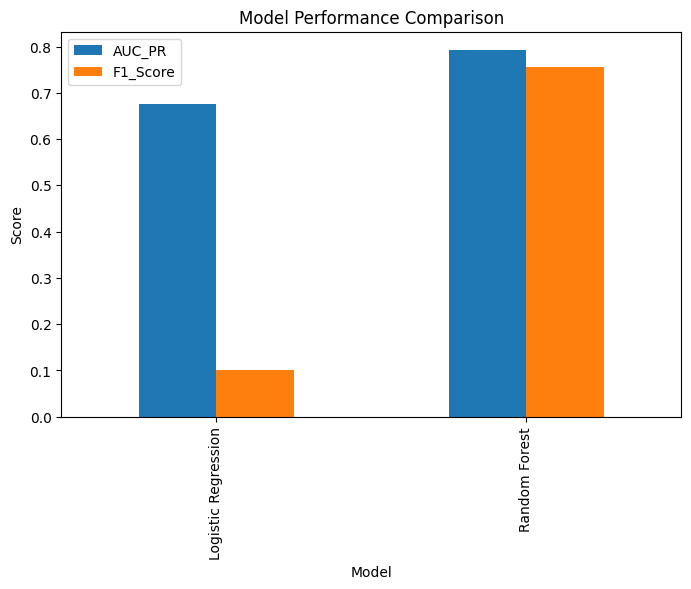

In [39]:
credit_comparison.plot(
    x="Model",
    y=["AUC_PR", "F1_Score"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

## Model performace comparison for Credit_card dataset interpretation
#### Overall Model Comparison

The chart clearly demonstrates that Random Forest performs better across both evaluation metrics:

#### Logistic Regression

-  Strengths

Reasonably good AUC-PR score.
Able to identify a high proportion of risky customers.

-  Weaknesses

Extremely low F1 Score.
Large number of false positives.
Poor precision despite high recall.
Random Forest

-  Strengths

Highest AUC-PR score.
Strong F1 Score.
Better balance between precision and recall.
Significantly fewer false positive predictions.

-  Weaknesses

Slightly more computationally expensive to train than Logistic Regression.
#### Generally 
The model comparison results show that Random Forest substantially outperforms Logistic Regression for credit risk prediction. Random Forest achieved an AUC-PR score of 0.792 and an F1 Score of 0.756, compared to 0.675 and 0.100 for Logistic Regression, respectively. The higher AUC-PR indicates a superior ability to distinguish between risky and non-risky customers, while the significantly higher F1 Score demonstrates a much better balance between precision and recall. These results suggest that Random Forest is the preferred model for credit risk assessment and is more suitable for deployment in practical lending and risk management applications.


In [42]:
feature_names = preprocessor.get_feature_names_out()

#### Feature Importance (Random Forest)

In [43]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

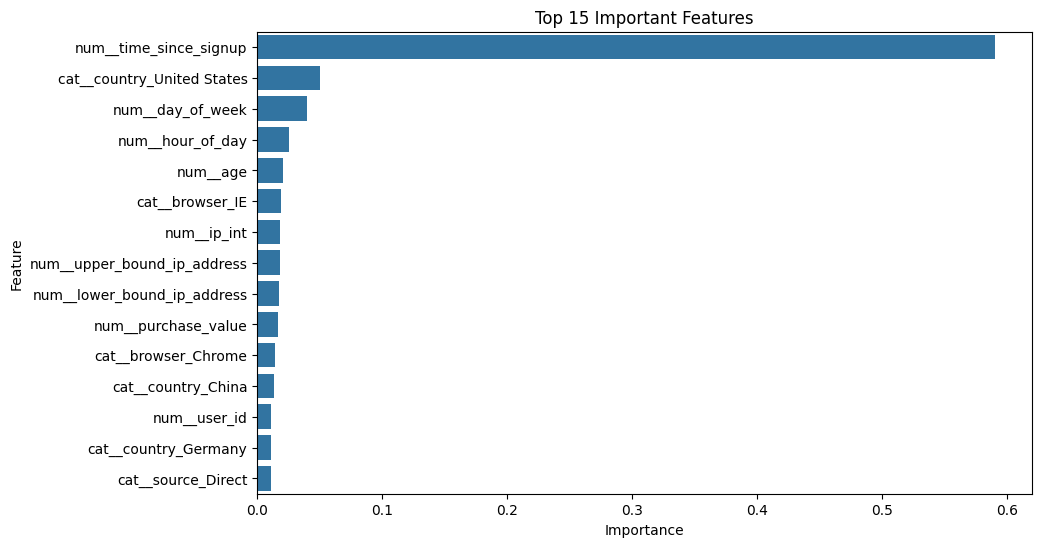

In [44]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

### Interpretation

The Random Forest feature importance analysis reveals that time since signup is the most influential predictor of fraudulent activity, contributing substantially more than any other feature. This suggests that newly created accounts are significantly more likely to engage in fraudulent transactions. Geographic variables, including country and IP address information, also play an important role, indicating that transaction origin is a key fraud indicator. Temporal features such as day of week and hour of day further contribute to prediction performance, highlighting the importance of transaction timing. Browser type and customer demographics provide additional predictive value. Overall, the results demonstrate that behavioral, geographic, and temporal characteristics are the primary drivers of fraud detection, providing valuable insights for developing targeted fraud prevention strategies.

## Final Model Selection Conclusion
Based on the experimental results obtained from both the Fraud Detection and Credit Risk datasets, the Random Forest classifier consistently outperformed Logistic Regression across all key evaluation metrics, including AUC-PR, F1 Score, and confusion matrix performance. This demonstrates its superior ability to learn complex, non-linear relationships within highly imbalanced financial datasets.

For the Fraud Detection dataset, Random Forest achieved substantially higher AUC-PR and F1 scores while significantly reducing false positive predictions compared to Logistic Regression. Similarly, for the Credit Risk dataset, Random Forest provided a much stronger balance between precision and recall, resulting in more accurate identification of high-risk customers while minimizing the number of incorrectly flagged low-risk customers.

The superior performance of Random Forest can be attributed to its ensemble learning approach, which combines multiple decision trees to capture intricate interactions among transaction, customer, and behavioral features that linear models often fail to detect. This capability is particularly important in fraud detection, where fraudulent activities frequently exhibit complex and evolving patterns.

Therefore, Random Forest is selected as the final model for fraud detection and risk classification. Its higher predictive accuracy, stronger Precision-Recall performance, improved F1 score, and better handling of class imbalance make it the most reliable model for identifying fraudulent transactions while minimizing false alerts. From a business perspective, this translates into more effective fraud prevention, reduced financial losses, improved operational efficiency, and a better customer experience by avoiding unnecessary transaction blocks.

### Final Recommendation

Based on the comparative analysis, the Random Forest model is recommended as the production-ready solution for fraud detection and credit risk assessment. Its consistent superiority across multiple evaluation metrics demonstrates its effectiveness in detecting fraudulent and high-risk activities while maintaining a strong balance between detection capability and false alarm reduction. Consequently, Random Forest provides the most robust and practical framework for supporting data-driven decision-making in financial risk management systems.

### Save Logistic Regression

In [45]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    lr_model,
    "../models/logistic_regression.pkl"
)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


### Save Random Forest

In [52]:
import joblib
import os

os.makedirs("../models", exist_ok=True)


joblib.dump(preprocessor,
    "../models/preprocessor.pkl")
joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

print("Random Forest model saved successfully.")
print("Preprocessor saved successfully.")

Random Forest model saved successfully.
Preprocessor saved successfully.


In [47]:
import joblib

rf_model = joblib.load(
    "../models/random_forest.pkl"
)

lr_model = joblib.load(
    "../models/logistic_regression.pkl"
)

### Trainig XGBoost Model

In [48]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### XGBClassifier Evaluation:

In [49]:
xgb_results = evaluate_model(
    xgb_model,
    X_test_processed,
    y_test
)

xgb_results

{'AUC_PR': 0.6185436071235777,
 'F1_Score': 0.6975533576262364,
 'Confusion_Matrix': array([[23328,    48],
        [ 1114,  1340]])}

### XGBoost Results Interpretation
-  AUC-PR = 0.6185

This is Precision-Recall AUC, very important for imbalanced datasets (like fraud detection).

0.5 = random model
1.0 = perfect model
0.62 = moderate performance
-  F1 Score = 0.6976

F1 balances precision + recall. This is actually quite decent (~0.70):Suggests a good trade-off Model is not extremely biased toward only precision or recall
-  Confusion Matrix
[[23328    48]
 [ 1114  1340]]

Let’s decode it:
|                   | Predicted Normal | Predicted Fraud |
| ----------------- | ---------------- | --------------- |
| **Actual Normal** | 23328 (TN)       | 48 (FP)         |
| **Actual Fraud**  | 1114 (FN)        | 1340 (TP)       |

#### What this means:
#### Strengths
-  Very low false positives (48) → good for reducing unnecessary fraud alerts
-  Detects 1340 fraud cases correctly
#### Weaknesses
-  False Negatives = 1114 (HIGH)
-  many fraud cases are still being missed
-  This is critical in fraud detection: Missing fraud (FN) is usually more expensive than false alarms.

#### Overall XGBoost Summary

-   Good balanced performance (F1 ~0.70)
-  Strong at avoiding false alarms
#####  Still misses many fraud cases
-  Moderate PR-AUC indicates room for improvement in minority detection

#### Comparison with Random Forest (Conceptual)

Since you didn’t provide Random Forest results, here’s how they usually compare:

#### Random Forest typically:
-  More stable and interpretable
-  Often higher recall on minority class (sometimes)
-  Can struggle with very imbalanced datasets unless tuned
#### XGBoost typically:
-  Better at learning complex patterns
-  Usually gives higher precision + better ranking (AUC-PR)
-  More sensitive to tuning

Once you share RF results, compare:
| Metric               | Better Model Indicator          |
| -------------------- | ------------------------------- |
| AUC-PR               | Higher = better fraud ranking   |
| F1 Score             | Higher = better balance         |
| Recall (Fraud class) | Higher = fewer missed frauds    |
| False Negatives      | Lower = better (very important) |

Even though XGBoost has decent F1:

-  The biggest issue is False Negatives (1114 fraud cases missed)

-  In real fraud systems:

    -  Missing fraud = high financial risk
    -  So you may want:
    -  threshold tuning (not default 0.5)
    -  SMOTE / class weighting
    -   recall-optimized model selection
